In [1]:
# LVDT_simulation/tests/demo.ipynb
import sys
sys.path.append('../../')
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from core import data_handler
from utils.vc_analyser import VC_Calculator, VC_Analyser


## LVDT 

#### 1.1 Simulation: 8mm vs 7.6mm offset comparison

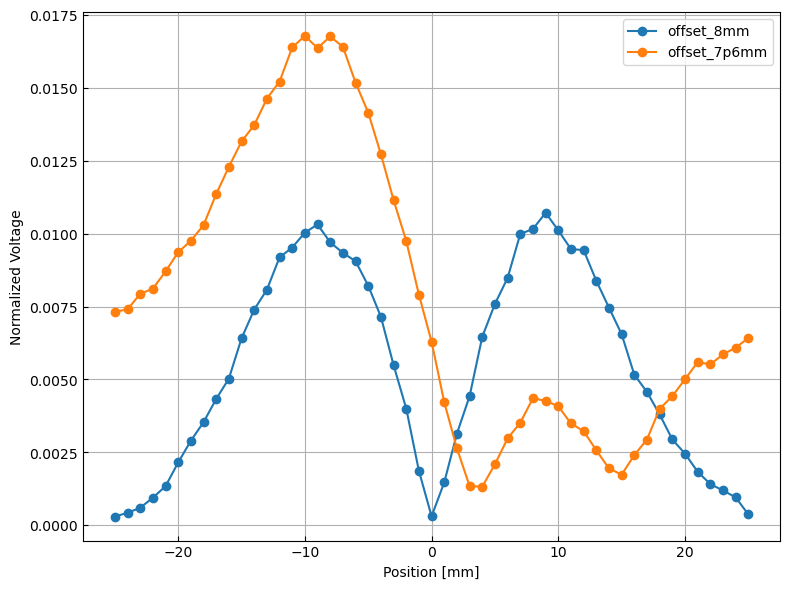

In [48]:
sim_filenames = ["../data/prototype_validation/lvdt/lvdt_simulation_alucoil_50mm_1mm_offset_8mm.h5",
                "../data/prototype_validation/lvdt/lvdt_simulation_alucoil_50mm_1mm_offset_7p6mm.h5"]
plt.figure(figsize=(8,6))
for sim_filename in sim_filenames:
    data_dict = data_handler.load_data(sim_filename)
    lvdt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage' ,flip_sign=False)
    sim_pos = lvdt_data['position']
    sim_input_volt = np.mean(abs(lvdt_data['Lower_Coil']['voltage_abs']))*2 # sum of two excitation coils
    sim_pickup_volt = np.array(lvdt_data['Middle_Coil']['voltage_abs'])
    sim_pickup_volt_norm = (sim_pickup_volt / sim_input_volt) 
    
    label = sim_filename.split('_1mm_')[-1].split(".")[0]

    plt.plot(sim_pos, sim_pickup_volt_norm, label=label, marker = 'o')
    plt.xlabel('Position [mm]')
    plt.ylabel('Normalized Voltage')
    plt.tick_params(direction='in')
plt.grid(True)
plt.legend()
plt.tight_layout()

#### 1.2 measurement: check the amplification difference

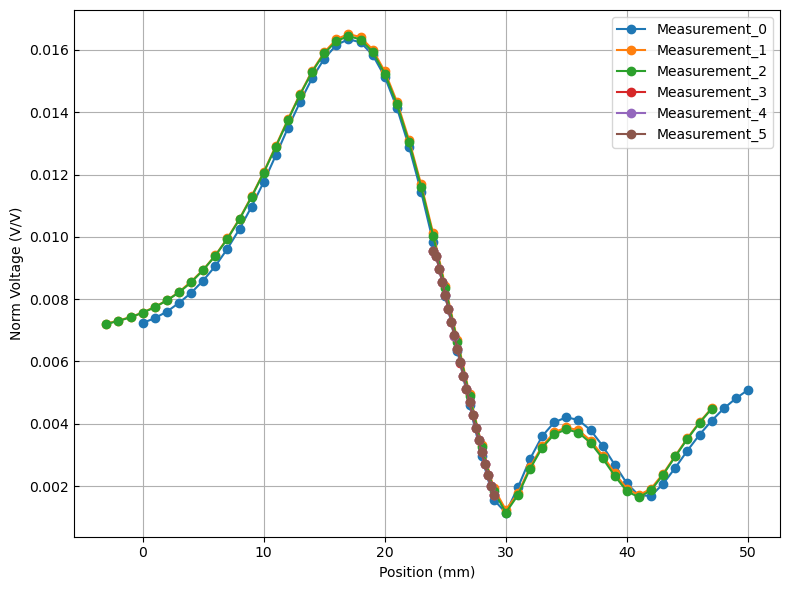

In [86]:
exp_files_50mm = ['../data/prototype_validation/lvdt/lvdt_measurement_alucoil_50mm_1mm_offset_01_6V.h5',
                  '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_50mm_1mm_offset_11_5V.h5',
                  '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_50mm_1mm_offset_21_6V.h5',
                  '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_5mm_0p25mm_offset_01_6V.h5',
                  '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_5mm_0p25mm_offset_02_6V.h5',
                  '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_5mm_0p25mm_offset_03_6V.h5',]

correction_factor = 1.23

plt.figure(figsize=(8,6))
for i, file in enumerate(exp_files_50mm):
    f = h5py.File(file, 'r')
    exp_pos = np.array(f['PI'][:])
    exp_pickup_amp = np.array(f['Fit_Amp'][:])
    exp_input_waveform = np.array(f['excitation'][:])
    exp_pickup_waveform = np.array(f['pick-up'][:])

    exp_input_volt = np.mean([np.std(x)*np.sqrt(2) for x in exp_input_waveform]) # it is already the readout from two excitation coils
    exp_pickup_volt = np.array([np.std(x)*np.sqrt(2) for x in exp_pickup_waveform])
    exp_pickup_volt_norm = (exp_pickup_volt / exp_input_volt)
    if i != 0:
        exp_pos = exp_pos - 3
        exp_pickup_volt_norm = exp_pickup_volt_norm * correction_factor
    
    plt.plot(exp_pos, exp_pickup_volt_norm, marker = 'o', label=f'Measurement_{i}')
    plt.xlabel('Position (mm)')
    plt.ylabel('Norm Voltage (V/V)')
    plt.tick_params(axis='y', direction='in')
    plt.legend()
    plt.grid(True)
plt.tight_layout()

#### 5mm range comparison

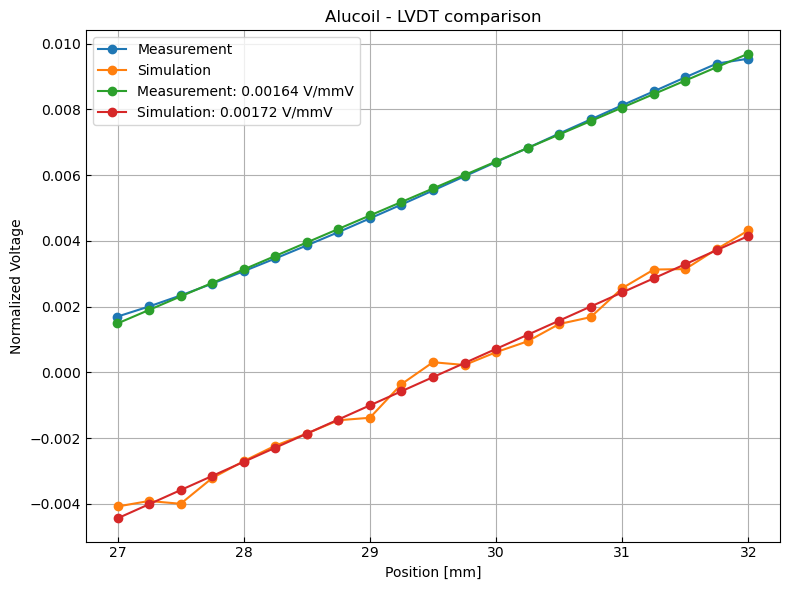

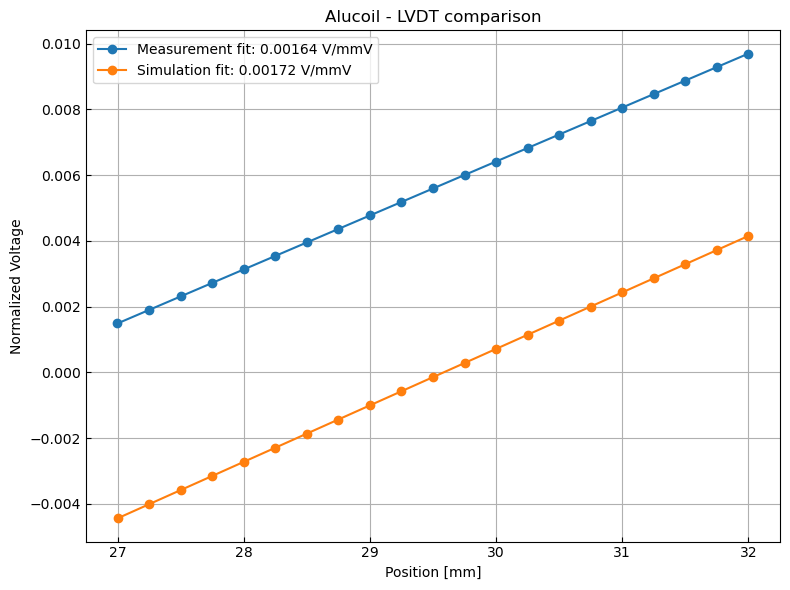

In [93]:
# measurement datas
exp_file = '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_5mm_0p25mm_offset_01_6V.h5'

f = h5py.File(exp_file, 'r')
exp_pos = np.array(f['PI'][:])
exp_pickup_amp = np.array(f['Fit_Amp'][:])
exp_input_waveform = np.array(f['excitation'][:])
exp_pickup_waveform = np.array(f['pick-up'][:])
exp_input_volt = np.mean([np.std(x)*np.sqrt(2) for x in exp_input_waveform]) # it is already the readout from two excitation coils
exp_pickup_volt = np.array([np.std(x)*np.sqrt(2) for x in exp_pickup_waveform])
exp_pickup_volt_norm = (exp_pickup_volt / exp_input_volt) [::-1]* correction_factor
exp_fit_data = data_handler.linear_analysis_FS(exp_pos,exp_pickup_volt_norm)

# simulation data
sim_file = "../data/prototype_validation/lvdt/lvdt_simulation_alucoil_5mm_0p25mm_offset_7p6mm.h5"
data_dict = data_handler.load_data(sim_file)
lvdt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage' ,flip_sign=True)
sim_pos = np.array(lvdt_data['position'])+29.5
sim_input_volt = np.mean(abs(lvdt_data['Lower_Coil']['voltage_abs']))*2 # sum of two excitation coils
sim_pickup_volt = np.array(lvdt_data['Middle_Coil']['voltage_abs'])
sim_pickup_volt_norm = (sim_pickup_volt / sim_input_volt)
sim_fit_data = data_handler.linear_analysis_FS(sim_pos,sim_pickup_volt_norm)

plt.figure(figsize=(8,6))
plt.plot(exp_pos, exp_pickup_volt_norm, label = 'Measurement', marker = 'o')
plt.plot(sim_pos, sim_pickup_volt_norm, label='Simulation', marker = 'o')
plt.plot(exp_pos, exp_fit_data['predict'], 
         label = f'Measurement: {exp_fit_data['response']['slope']:.5f} V/mmV', marker = 'o')
plt.plot(sim_pos, sim_fit_data['predict'], 
         label=f'Simulation: {sim_fit_data['response']['slope']:.5f} V/mmV', marker = 'o')
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Voltage')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend()
plt.title('Alucoil - LVDT comparison')
plt.tight_layout()


plt.figure(figsize=(8,6))
plt.plot(exp_pos, exp_fit_data['predict'], 
         label = f'Measurement fit: {exp_fit_data['response']['slope']:.5f} V/mmV', marker = 'o')
plt.plot(sim_pos, sim_fit_data['predict'], 
         label=f'Simulation fit: {sim_fit_data['response']['slope']:.5f} V/mmV', marker = 'o')
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Voltage')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend()
plt.title('Alucoil - LVDT comparison')
plt.tight_layout()

# plt.figure(figsize=(8,6))

# plt.xlabel('Position [mm]')
# plt.ylabel('Normalized Voltage')
# plt.tick_params(direction='in')
# plt.grid(True)
# plt.legend()
# plt.title('Alucoil - LVDT comparison')
# plt.tight_layout()

#### 50mm range comparison

0.0016294108154782893


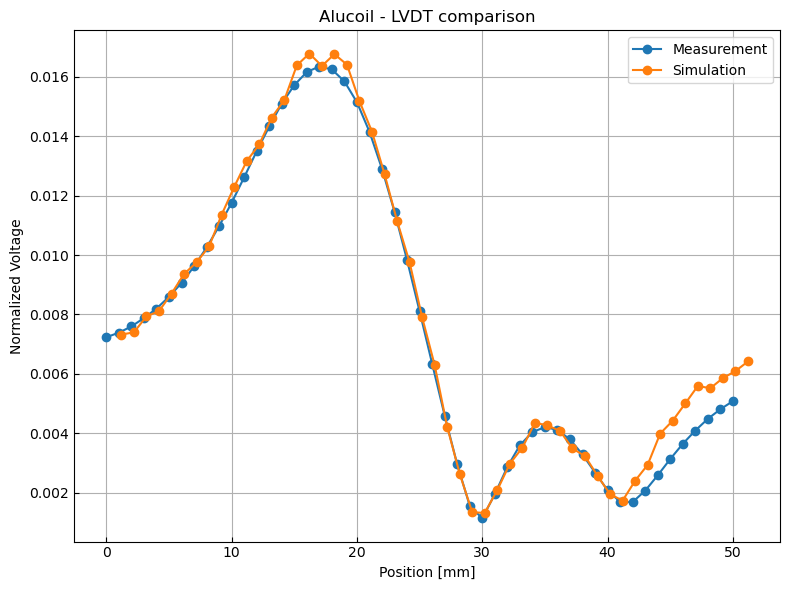

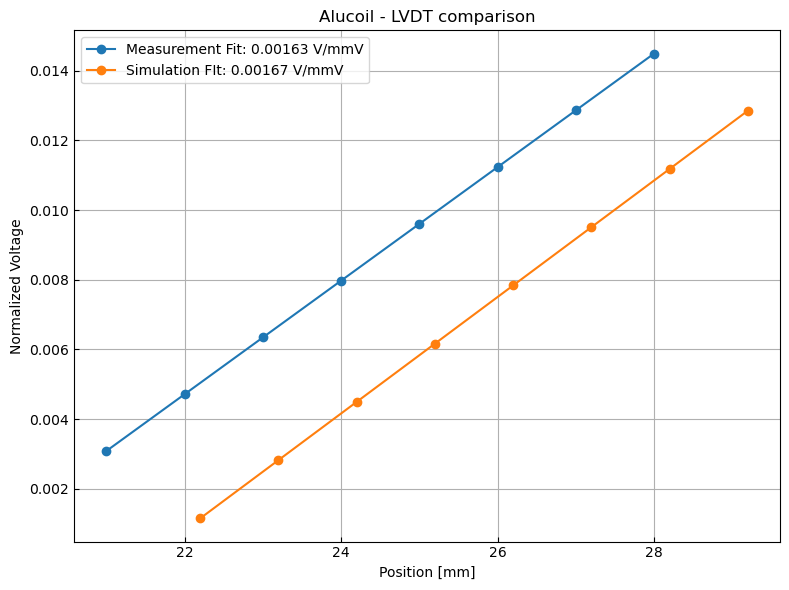

In [94]:
# measurement datas
exp_file = '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_50mm_1mm_offset_01_6V.h5'
f = h5py.File(exp_file, 'r')
exp_pos = np.array(f['PI'][:])
exp_pickup_amp = np.array(f['Fit_Amp'][:])
exp_input_waveform = np.array(f['excitation'][:])
exp_pickup_waveform = np.array(f['pick-up'][:])
exp_input_volt = np.mean([np.std(x)*np.sqrt(2) for x in exp_input_waveform]) # it is already the readout from two excitation coils
exp_pickup_volt = np.array([np.std(x)*np.sqrt(2) for x in exp_pickup_waveform])
exp_pickup_volt_norm = (exp_pickup_volt / exp_input_volt)#*1.25
exp_fit_data = data_handler.linear_analysis_FS(exp_pos[21:29],exp_pickup_volt_norm[21:29][::-1])

print(exp_fit_data['response']['slope'])

# simulation data
sim_file = "../data/prototype_validation/lvdt/lvdt_simulation_alucoil_50mm_1mm_offset_7p6mm.h5"
data_dict = data_handler.load_data(sim_file)
lvdt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage' ,flip_sign=False)
sim_pos = lvdt_data['position']+26.2
sim_input_volt = np.mean(abs(lvdt_data['Lower_Coil']['voltage_abs']))*2 # sum of two excitation coils
sim_pickup_volt = np.array(lvdt_data['Middle_Coil']['voltage_abs'])
sim_pickup_volt_norm = (sim_pickup_volt / sim_input_volt) 
sim_fit_data = data_handler.linear_analysis_FS(sim_pos[21:29],sim_pickup_volt_norm[21:29][::-1])

plt.figure(figsize=(8,6))
plt.plot(exp_pos, exp_pickup_volt_norm, label='Measurement', marker = 'o')
plt.plot(sim_pos, sim_pickup_volt_norm, label='Simulation', marker = 'o')
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Voltage')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend()
plt.title('Alucoil - LVDT comparison')
plt.tight_layout()

plt.figure(figsize=(8,6))
plt.plot(exp_pos[21:29], exp_fit_data['predict'], 
         label = f'Measurement Fit: {exp_fit_data['response']['slope']:.5f} V/mmV', marker = 'o')
plt.plot(sim_pos[21:29], sim_fit_data['predict'],
            label=f'Simulation FIt: {sim_fit_data['response']['slope']:.5f} V/mmV', marker = 'o')
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Voltage')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend()
plt.title('Alucoil - LVDT comparison')
plt.tight_layout()

# plot
# figure, ax1 = plt.subplots(figsize=(8,6))
# ax1.plot(sim_pos, sim_pickup_volt_norm, marker = 'o', label='Simulation', color='tab:red')
# ax1.set_ylabel('Norm Voltage (V/V)', color='tab:red')
# ax1.tick_params(axis='y', labelcolor='tab:red', direction='in')
# ax1.legend(loc='upper left')
# ax1.grid()
# ax2 = ax1.twinx()
# ax2.plot(exp_pos, exp_pickup_volt_norm, marker = 'o', label='Measurement', color='tab:blue')
# ax2.set_xlabel('Position (mm)')
# ax2.set_ylabel('Norm Voltage (V/V)', color='tab:blue')
# ax2.tick_params(axis='y', labelcolor='tab:blue', direction='in')
# ax2.legend(loc='upper right')

# plt.title('Alucoil - LVDT comparison')
# plt.tight_layout()
# plt.savefig('../result/comparison_lvdt_50mm.pdf', dpi=300, bbox_inches='tight')

## VC

### 8mm vs 7.6mm offset comparison

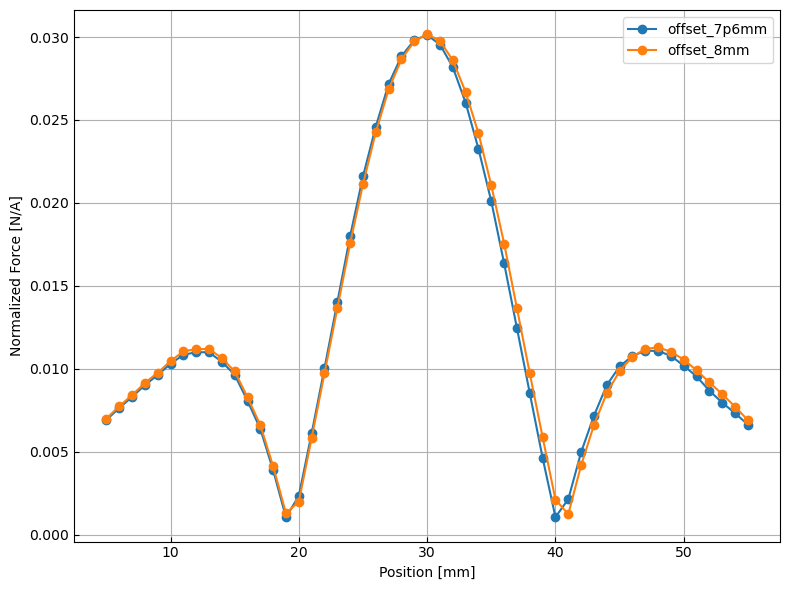

In [56]:
# simulation data
sim_filenames = ["../data/prototype_validation/vc/vc_simulation_alucoil_50mm_1mm_offset_7p6mm.h5",
                 "../data/prototype_validation/vc/vc_simulation_alucoil_50mm_1mm_offset_8mm.h5"]

plt.figure(figsize=(8,6))
for sim_filename in sim_filenames:
    sim_data_dict = data_handler.load_data(sim_filename)
    sim_config_data = data_handler.get_config_data(sim_data_dict)
    sim_vc_data = data_handler.get_vc_data(sim_data_dict)

    sim_position = sim_vc_data['position']+30
    sim_tot_force = abs((sim_vc_data['Lower_Coil']['force'])+(sim_vc_data['Upper_Coil']['force']))
    sim_norm_force = np.array(sim_tot_force)/0.06
    sim_max_norm_force = max(sim_norm_force)
    sim_fvi = ((1 - sim_norm_force )/ sim_max_norm_force) * 100
    label = sim_filename.split('_1mm_')[-1].split(".")[0]

    plt.plot(sim_position, sim_norm_force, label=label, marker = 'o')
    plt.xlabel('Position [mm]')
    plt.ylabel('Normalized Force [N/A]')
    plt.tick_params(direction='in')

plt.grid(True)
plt.legend()
plt.tight_layout()


### 20mm range comparison

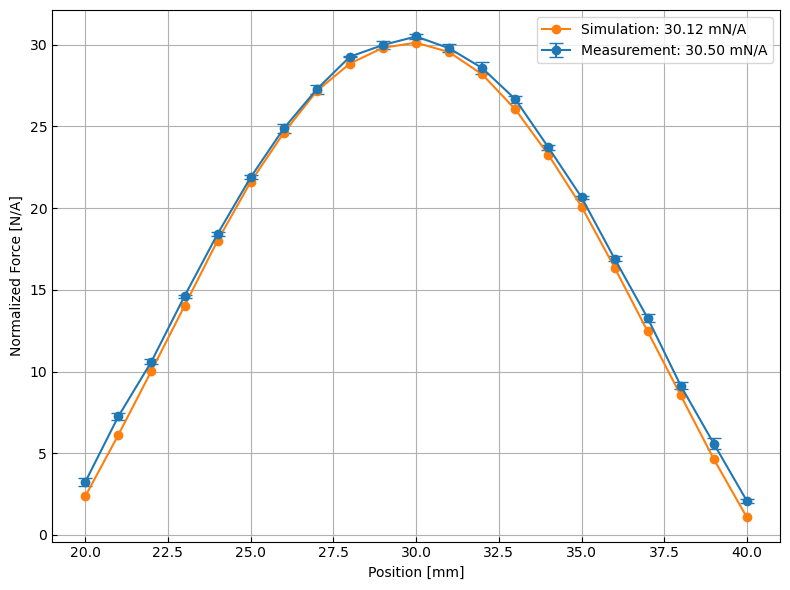

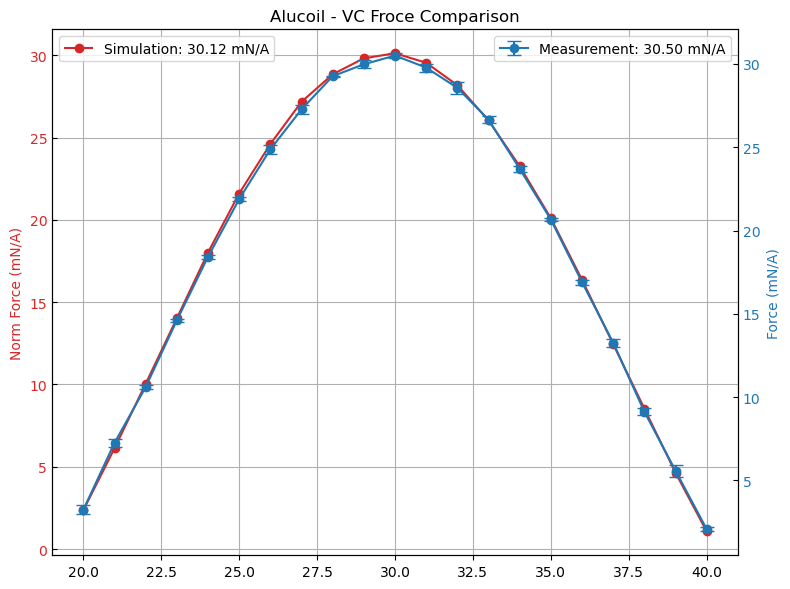

In [60]:
# measurement data dict
exp_dict = {
    "43gram":["../data/prototype_validation/vc/vc_measurement_alucoil_20mm_1mm_offset_01.h5",
              "../data/prototype_validation/vc/vc_measurement_alucoil_20mm_1mm_offset_02.h5",
              "../data/prototype_validation/vc/vc_measurement_alucoil_20mm_1mm_offset_03.h5",]
}

vc_analyser = VC_Analyser(exp_dict)
vc_result = vc_analyser.calculate_for_all_datasets(norm=True)
exp_position = vc_result['43gram'][0]['position']
exp_force_avg = vc_result['43gram'][0]['mean']
exp_force_std = vc_result['43gram'][0]['std']
exp_position = np.array(exp_position)
exp_force_avg = np.array(exp_force_avg)*1000
exp_force_std = np.array(exp_force_std)*1000
exp_max_force = max(exp_force_avg)

# simulation data
sim_filename = "../data/prototype_validation/vc/vc_simulation_alucoil_20mm_1mm_offset_7p6mm.h5"

sim_data_dict = data_handler.load_data(sim_filename)
sim_config_data = data_handler.get_config_data(sim_data_dict)
sim_vc_data = data_handler.get_vc_data(sim_data_dict)

sim_position = sim_vc_data['position']+30
sim_tot_force = abs((sim_vc_data['Lower_Coil']['force'])+(sim_vc_data['Upper_Coil']['force']))
sim_norm_force = np.array(sim_tot_force)*1000/0.06
sim_max_norm_force = max(sim_norm_force)
sim_fvi = ((1 - sim_norm_force )/ sim_max_norm_force) * 100

plt.figure(figsize=(8,6))
plt.errorbar(exp_position, exp_force_avg, yerr = exp_force_std, fmt='o-', capsize=5, label=f'Measurement: {exp_max_force:.2f} mN/A')
plt.plot(sim_position, sim_norm_force, marker = 'o', label=f'Simulation: {sim_max_norm_force:.2f} mN/A')
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Force [N/A]')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend()
plt.tight_layout()

# plot
figure, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(sim_position, sim_norm_force, marker = 'o', label=f'Simulation: {sim_max_norm_force:.2f} mN/A', color='tab:red')
ax1.set_ylabel('Norm Force (mN/A)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red', direction='in')
ax1.legend(loc='upper left')
ax1.grid()

ax2 = ax1.twinx()
ax2.errorbar(exp_position, exp_force_avg, yerr=exp_force_std, fmt='o-', capsize=5, label=f'Measurement: {exp_max_force:.2f} mN/A', color='tab:blue')
ax2.set_xlabel('Position (mm)')
ax2.set_ylabel('Force (mN/A)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue', direction='in')
ax2.legend(loc='upper right')

plt.title('Alucoil - VC Froce Comparison')
plt.tight_layout()
# plt.savefig('../result/comparison_voicecoil_20mm.pdf', dpi=300, bbox_inches='tight')

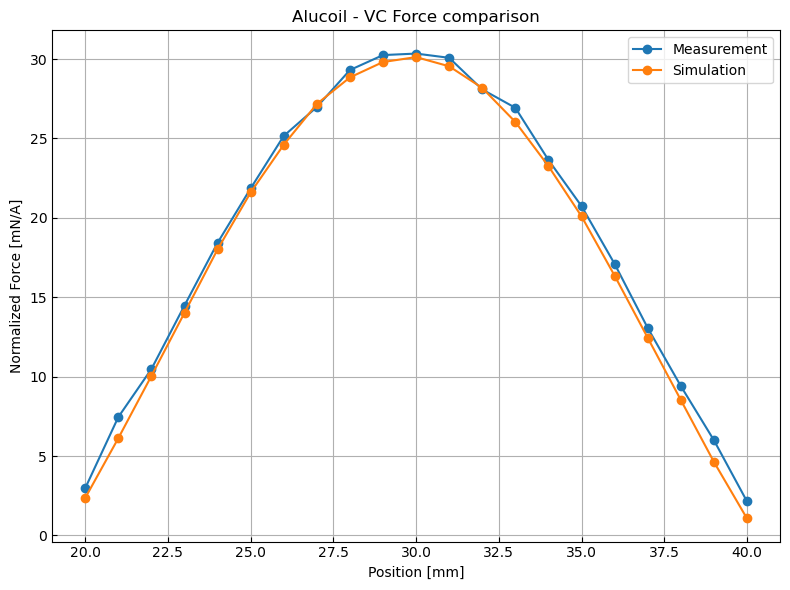

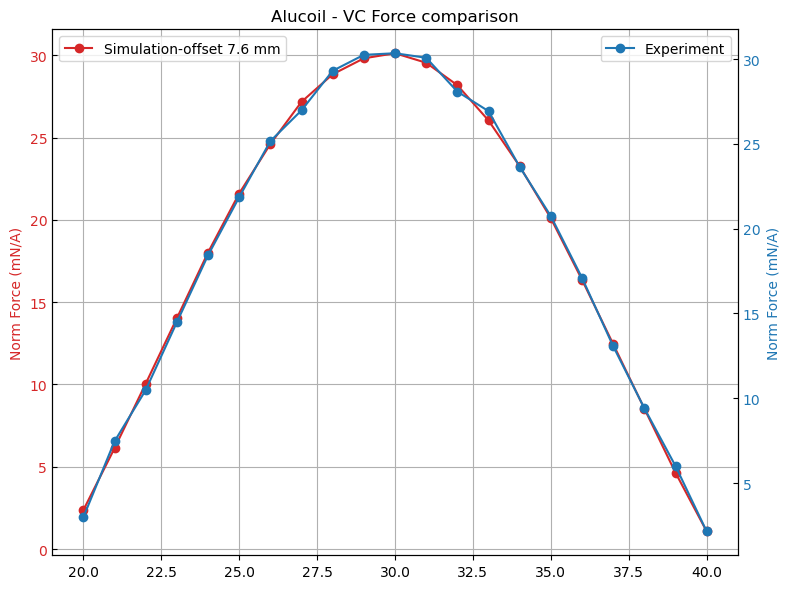

In [61]:
# measurement data
exp_filename = "../data/prototype_validation/vc/vc_measurement_alucoil_20mm_1mm_offset_01.h5"

vc_calculator = VC_Calculator()
exp_data_dict, curr = vc_calculator.force_calculation(exp_filename, norm=True)
exp_data_sorted = sorted(exp_data_dict.items(), key = lambda item: float(item[0]))

exp_position = []
exp_norm_force = []
for item in exp_data_sorted:
    exp_position.append(float(item[0]))
    exp_norm_force.append(item[1])

exp_position = np.array(exp_position)
exp_norm_force = np.array(exp_norm_force)*1000
# simulation data
sim_filename = "../data/prototype_validation/vc/vc_simulation_alucoil_20mm_1mm_offset_7p6mm.h5"

sim_data_dict = data_handler.load_data(sim_filename)
sim_config_data = data_handler.get_config_data(sim_data_dict)
sim_vc_data = data_handler.get_vc_data(sim_data_dict)

sim_position = sim_vc_data['position'] + 30
sim_tot_force = abs((sim_vc_data['Lower_Coil']['force'])+(sim_vc_data['Upper_Coil']['force']))
sim_norm_force = np.array(sim_tot_force)*1000/0.06
sim_max_norm_force = max(sim_norm_force)
sim_fvi = ((1 - sim_norm_force )/ sim_max_norm_force) * 100

plt.figure(figsize=(8,6))
plt.plot(exp_position, exp_norm_force, label='Measurement', marker = 'o')
plt.plot(sim_position, sim_norm_force, label='Simulation', marker = 'o')
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Force [mN/A]')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend()
plt.title('Alucoil - VC Force comparison')
plt.tight_layout()

# plot
figure, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(sim_position, sim_norm_force, marker = 'o', label='Simulation-offset 7.6 mm', color='tab:red')
ax1.set_ylabel('Norm Force (mN/A)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red', direction='in')
ax1.legend(loc='upper left')
ax1.grid()

ax2 = ax1.twinx()
ax2.plot(exp_position, exp_norm_force, marker = 'o', label='Experiment', color='tab:blue')
ax2.set_xlabel('Position (mm)')
ax2.set_ylabel('Norm Force (mN/A)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue', direction='in')
ax2.legend(loc='upper right')

plt.title('Alucoil - VC Force comparison')
plt.tight_layout()

### 50mm range comparison

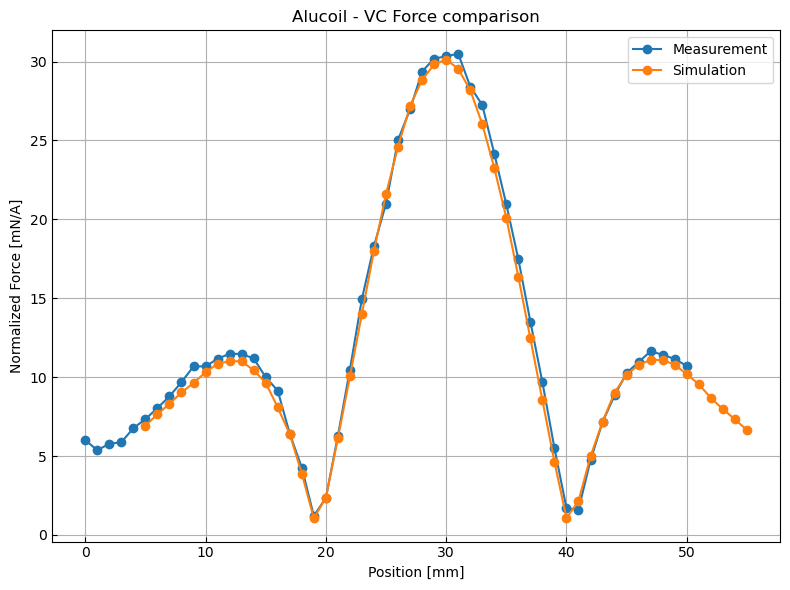

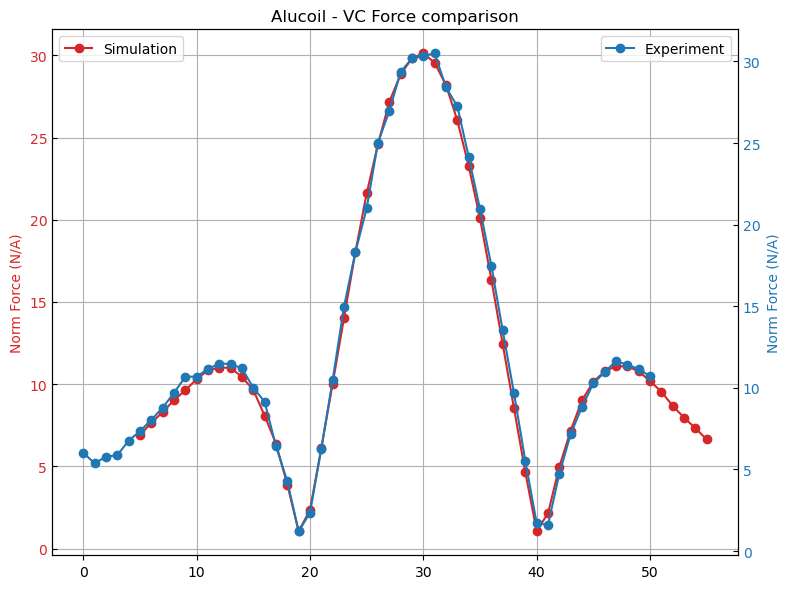

In [13]:
# measurement data
exp_filename = "../data/prototype_validation/vc/vc_measurement_alucoil_50mm_1mm_offset_01.h5"
vc_calculator = VC_Calculator()
exp_data_dict, curr = vc_calculator.force_calculation(exp_filename, norm=True)
exp_data_sorted = sorted(exp_data_dict.items(), key = lambda item: float(item[0]))

exp_position = []
exp_norm_force = []
for item in exp_data_sorted:
    exp_position.append(float(item[0]))
    exp_norm_force.append(item[1])
exp_position = np.array(exp_position)
exp_norm_force = np.array(exp_norm_force)*1000
# simulation data
sim_filename = "../data/prototype_validation/vc/vc_simulation_alucoil_50mm_1mm_offset_7p6mm.h5"

sim_data_dict = data_handler.load_data(sim_filename)
sim_config_data = data_handler.get_config_data(sim_data_dict)
sim_vc_data = data_handler.get_vc_data(sim_data_dict)

sim_position = sim_vc_data['position'] + 30
sim_tot_force = abs((sim_vc_data['Lower_Coil']['force'])+(sim_vc_data['Upper_Coil']['force']))
sim_norm_force = np.array(sim_tot_force)*1000/0.06
sim_max_norm_force = max(sim_norm_force)
sim_fvi = ((1 - sim_norm_force )/ sim_max_norm_force) * 100

plt.figure(figsize=(8,6))
plt.plot(exp_position, exp_norm_force, label='Measurement', marker = 'o')
plt.plot(sim_position, sim_norm_force, label='Simulation', marker = 'o')
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Force [mN/A]')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend()
plt.title('Alucoil - VC Force comparison')
plt.tight_layout()

# plot
figure, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(sim_position, sim_norm_force, marker = 'o', label='Simulation', color='tab:red')
ax1.set_ylabel('Norm Force (N/A)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red', direction='in')
ax1.legend(loc='upper left')
ax1.grid()

ax2 = ax1.twinx()
ax2.plot(exp_position, exp_norm_force, marker = 'o', label='Experiment', color='tab:blue')
ax2.set_xlabel('Position (mm)')
ax2.set_ylabel('Norm Force (N/A)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue', direction='in')
ax2.legend(loc='upper right')

plt.title('Alucoil - VC Force comparison')
plt.tight_layout()
# plt.savefig('../result/comparison_voicecoil_40mm.pdf', dpi=300, bbox_inches='tight')